## Hello world!

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

a = [[1, 2], [3, 4]]
b = [2, 4]
c = np.linalg.solve(a, b)  # exp [0, 1]
print(c)

[0. 1.]


## Mathplotlib

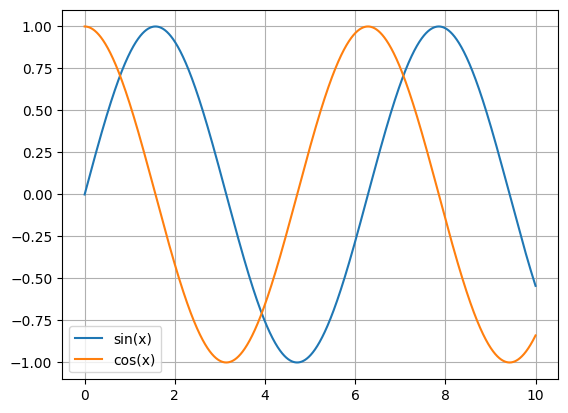

In [2]:
import matplotlib.pyplot as plt

x = np.linspace(0.0, 10.0, 5000)  # Старт конец точки
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.grid()
plt.legend()

## Pandas

In [3]:
import pandas as pd


def func(data):
    return {"text": f"x = {x}", "value": x**2}


data = [func(x) for x in range(100)]

In [4]:
df = pd.DataFrame(data)
df

,text,value
0,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
1,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
2,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
3,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
4,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
...,...,...
95,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
96,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
97,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."
98,x = [0.00000000e+00 2.00040008e-03 4.00080016e...,"[0.0, 4.001600480128032e-06, 1.600640192051213..."


Predict 1:  [1.10339549 0.97861064 0.51176757 1.19396726 1.02796712]
Predict 2:  [-43.51082641 -41.07903482 -31.98125513 -45.27587772 -42.0408876 ]


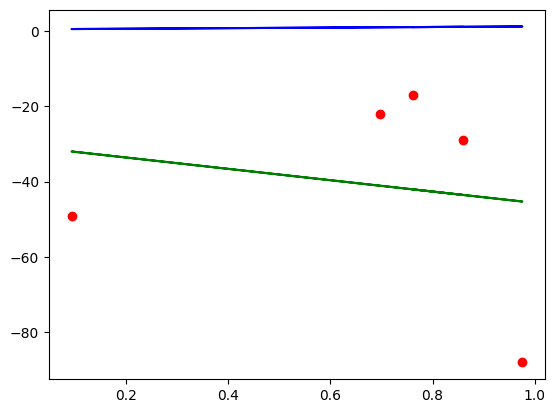

In [5]:
from students.kuzmin.lesson2 import Exercise

num_points = 5
num_features = 1

model = Exercise.create_linear_model(num_features, np.random.default_rng(42))

rng = np.random.default_rng(42)
weights = rng.random(num_features)
bias = np.array(rng.random())
x = rng.random((num_points, num_features))
y = rng.integers(-100, 0, num_points)
model.bias = bias

arr_x = np.array([1, 2, 3, 4, 5, 6])
arr_x = arr_x.reshape(-1, 1)

arr_y = np.array([1, 4, 2, 7, 10, 15])
SPACE = np.linspace(0.0, 10.0, 5000)  # Старт конец точки

plt.scatter(x, y, color="red")

print("Predict 1: ", model.predict(x))
plt.plot(x, model.predict(x), color="blue")

Exercise.fit(model, x, y, 0.05, 100, 5)

print("Predict 2: ", model.predict(x))
plt.plot(x, model.predict(x), color="green")

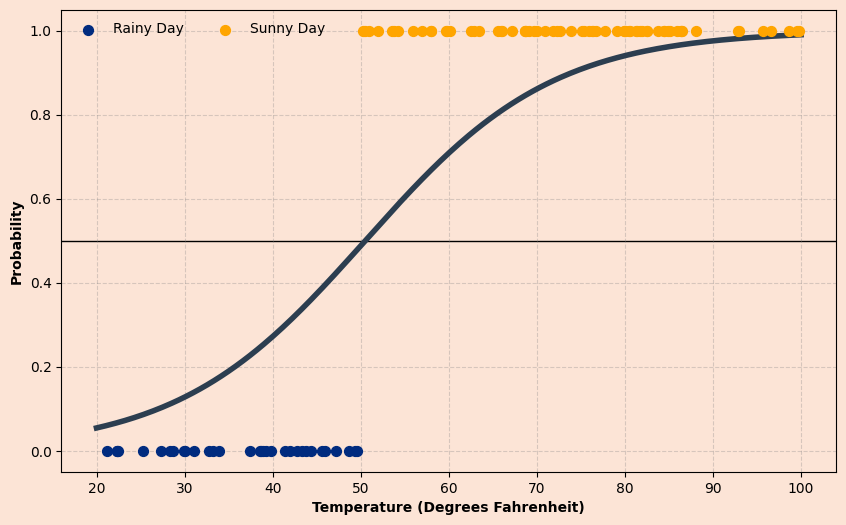

Accuracy: 98.00%


In [6]:
num_points = 100
num_features = 1

model = Exercise.create_logistic_model(num_features, np.random.default_rng(42))

rng = np.random.default_rng(np.random.randint(0, 100))
weights = rng.random(num_features)
bias = np.array(rng.random())

model.bias = bias

X_temp_raw = np.sort(np.random.uniform(20, 100, num_points))
y = (X_temp_raw > 50).astype(int)
X_matrix = X_temp_raw.reshape(-1, 1)  # X должен быть (100, 1)

X_mean = np.mean(X_matrix)
X_std = np.std(X_matrix)
X_scaled = (X_matrix - X_mean) / X_std

plt.figure(figsize=(10, 6), facecolor="#FCE4D6")  # Цвет фона как на картинке
ax = plt.gca()
ax.set_facecolor("#FCE4D6")  # Цвет фона для осей

Exercise.fit(model, X_scaled, y, lr=0.1, n_epoch=5, batch_size=5)

# Рисуем точки (используем сырые X_temp_raw для оси X, чтобы видеть градусы)
plt.scatter(X_temp_raw[y == 0], y[y == 0], color="#002B7F", label="Rainy Day", s=50, zorder=5)
plt.scatter(X_temp_raw[y == 1], y[y == 1], color="#FFA500", label="Sunny Day", s=50, zorder=5)

# Чтобы линия была плавной, создадим много точек X
X_smooth_raw = np.linspace(20, 100, 300).reshape(-1, 1)
# Нормализуем их теми же mean и std, на которых училась модель!
X_smooth_scaled = (X_smooth_raw - X_mean) / X_std
# Делаем предсказание
y_smooth_pred = model.predict(X_smooth_scaled)

# Рисуем предсказанную вероятность (S-кривую)
plt.plot(X_smooth_raw, y_smooth_pred, color="#2C3E50", linewidth=4, zorder=4)

# Оформление графика
plt.axhline(0.5, color="black", linewidth=1, zorder=1)  # Линия 0.5
plt.grid(color="gray", linestyle="--", alpha=0.3)
plt.xlabel("Temperature (Degrees Fahrenheit)", fontweight="bold")
plt.ylabel("Probability", fontweight="bold")
plt.legend(frameon=False, loc="upper left", ncol=2)
plt.show()
# Проверка метрики
print(f"Accuracy: {model.metric(X_scaled, y):.2%}")

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)
print(f"X_train size: {X_train.shape}")
print(f"X_val size: {X_val.shape}")
num_points = 100
num_features = 4

model = Exercise.create_logistic_model(num_features, np.random.default_rng(42))

rng = np.random.default_rng(np.random.randint(0, 100))
weights = rng.random(num_features)
bias = np.array(rng.random())

model.bias = bias
y_train = (y_train == 0).astype(int)
Exercise.fit(model, X_train, y_train, 0.1, 16, 5)  # standart gradient descent = 16 iter, lr = 0.1
print(f"Accuracy: {model.metric(X_train, y_train)}")

X_train size: (90, 4)
X_val size: (30, 4)
Accuracy: 1.0


In [8]:
import numpy as np

arr1 = [1, 2, 3, 4]
arr2 = ["a", "b", "c", "d"]

seed = np.random.randint(0, 100)
np.random.seed(seed)
np.random.shuffle(arr1)
np.random.seed(seed)
np.random.shuffle(arr2)


print(arr1)
print(arr2)

for i in range(0, len(arr1), 2):
    print(arr1[i : i + 2])

[4, 2, 3, 1]
['d', 'b', 'c', 'a']
[4, 2]
[3, 1]
